# Libraries Imported

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import random
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image
import time
import tempfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import seaborn as sns

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

# Reading Dataset

In [2]:
zip_path = "/content/drive/MyDrive/AI ML Course/Data/mudra (1).zip"
extract_path = "/content/Bharatanatyam_Mudras"

In [3]:
import zipfile

# Extract the zip file first
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
# Now define dataset_dir based on the extracted path
dataset_dir = os.path.join(extract_path, "Bharatanatyam_Mudras")

In [5]:
print(os.listdir(dataset_dir))

['Trisula', 'Simhamukha', 'Musti', 'Sikhara', 'Pataka']


In [6]:
categories = [
    'Trisula',
    'Simhamukha',
    'Musti',
    'Sikhara',
    'Pataka'
]

In [7]:
print("Number of classes:", len(categories))
print("Classes:", categories)

Number of classes: 5
Classes: ['Trisula', 'Simhamukha', 'Musti', 'Sikhara', 'Pataka']


# EDA

In [8]:
# dataset_dir should point to the folder containing:
# Trisula, Simhamukha, Sikhara, Musti, Pataka
image_size = (224, 224)
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="int",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="int",
)

class_names = train_ds.class_names
num_classes = len(class_names)

normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE,
)
val_ds = val_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE,
)

train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 2000 files belonging to 5 classes.
Using 1600 files for training.
Found 2000 files belonging to 5 classes.
Using 400 files for validation.
Classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']
Number of classes: 5


In [9]:
class_names = ["Musti", "Pataka", "Sikhara", "Simhamukha", "Trisula"]
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

class_counts = Counter()
class_dimensions = defaultdict(list)
class_modes = defaultdict(Counter)
all_widths = []
all_heights = []
unreadable_images = []

for class_name in class_names:
    class_dir = Path(dataset_dir) / class_name

    for image_path in class_dir.rglob("*"):
        if image_path.suffix.lower() not in image_extensions:
            continue

        class_counts[class_name] += 1

        try:
            with Image.open(image_path) as image:
                width, height = image.size
                class_dimensions[class_name].append((width, height))
                class_modes[class_name][image.mode] += 1
                all_widths.append(width)
                all_heights.append(height)
        except Exception:
            unreadable_images.append(str(image_path))

print("Class distribution:")
for class_name in class_names:
    count = class_counts[class_name]
    percentage = count / sum(class_counts.values()) * 100 if sum(class_counts.values()) else 0
    print(f"{class_name}: {count} images ({percentage:.1f}%)")

print("\nImage characteristics by class:")
for class_name in class_names:
    dimensions = class_dimensions[class_name]

    if dimensions:
        widths, heights = zip(*dimensions)
        print(
            f"{class_name}: "
            f"{len(dimensions)} readable images, "
            f"width {min(widths)}-{max(widths)} (mean {np.mean(widths):.1f}), "
            f"height {min(heights)}-{max(heights)} (mean {np.mean(heights):.1f}), "
            f"modes {dict(class_modes[class_name])}"
        )
    else:
        print(f"{class_name}: no readable images")

if all_widths and all_heights:
    print("\nOverall image characteristics:")
    print(f"Width range: {min(all_widths)}-{max(all_widths)} pixels")
    print(f"Height range: {min(all_heights)}-{max(all_heights)} pixels")
    print(f"Mean dimensions: {np.mean(all_widths):.1f} x {np.mean(all_heights):.1f} pixels")

print(f"\nUnreadable images: {len(unreadable_images)}")

Class distribution:
Musti: 400 images (20.0%)
Pataka: 400 images (20.0%)
Sikhara: 400 images (20.0%)
Simhamukha: 400 images (20.0%)
Trisula: 400 images (20.0%)

Image characteristics by class:
Musti: 400 readable images, width 300-300 (mean 300.0), height 300-300 (mean 300.0), modes {'RGB': 400}
Pataka: 400 readable images, width 300-300 (mean 300.0), height 300-300 (mean 300.0), modes {'RGB': 400}
Sikhara: 400 readable images, width 300-300 (mean 300.0), height 300-300 (mean 300.0), modes {'RGB': 400}
Simhamukha: 400 readable images, width 300-300 (mean 300.0), height 300-300 (mean 300.0), modes {'RGB': 400}
Trisula: 400 readable images, width 300-300 (mean 300.0), height 300-300 (mean 300.0), modes {'RGB': 400}

Overall image characteristics:
Width range: 300-300 pixels
Height range: 300-300 pixels
Mean dimensions: 300.0 x 300.0 pixels

Unreadable images: 0


In [10]:
image_size = (224, 224)
batch_size = 32
seed = 42
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

# Match the alphabetical class order used by image_dataset_from_directory.
class_names = sorted(
    path.name for path in Path(dataset_dir).iterdir() if path.is_dir()
)
class_to_index = {name: index for index, name in enumerate(class_names)}

image_paths = []
labels = []

for class_name in class_names:
    for path in (Path(dataset_dir) / class_name).rglob("*"):
        if path.is_file() and path.suffix.lower() in valid_extensions:
            image_paths.append(str(path))
            labels.append(class_to_index[class_name])

# Split into 70% training, 15% validation, and 15% test.
train_paths, remaining_paths, train_labels, remaining_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=seed,
    stratify=labels,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    remaining_paths,
    remaining_labels,
    test_size=0.50,
    random_state=seed,
    stratify=remaining_labels,
)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(paths, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(paths), seed=seed)
    return (
        dataset
        .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

print("Classes:", class_names)
print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")

Classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']
Training images: 1400
Validation images: 300
Test images: 300


In [11]:
image_size = (224, 224)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

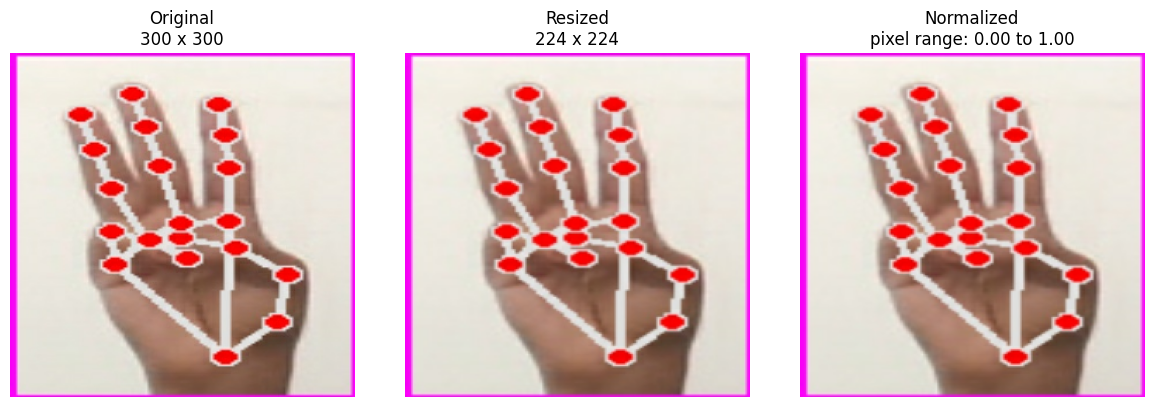

Original shape: (300, 300, 3)
Resized shape: (224, 224, 3)
Normalized pixel range: 0.0 to 1.0


In [12]:
image_size = (224, 224)
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

# Select one image from the dataset
sample_path = next(
    path
    for path in Path(dataset_dir).rglob("*")
    if path.is_file() and path.suffix.lower() in valid_extensions
)

# Load, resize, and normalize the image
image_bytes = tf.io.read_file(str(sample_path))
original_image = tf.io.decode_image(
    image_bytes, channels=3, expand_animations=False
).numpy()

resized_image = tf.image.resize(original_image, image_size).numpy()
normalized_image = resized_image / 255.0

# Display each processing stage
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(original_image)
axes[0].set_title(f"Original\n{original_image.shape[1]} x {original_image.shape[0]}")

axes[1].imshow(resized_image.astype("uint8"))
axes[1].set_title(f"Resized\n{image_size[1]} x {image_size[0]}")

axes[2].imshow(normalized_image)
axes[2].set_title(
    f"Normalized\npixel range: {normalized_image.min():.2f} to "
    f"{normalized_image.max():.2f}"
)

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

print("Original shape:", original_image.shape)
print("Resized shape:", resized_image.shape)
print(
    "Normalized pixel range:",
    float(normalized_image.min()),
    "to",
    float(normalized_image.max()),
)

In [13]:
# Assumes train_ds, val_ds, and test_ds contain resized images
# normalized to [0, 1]. Augmentation is applied only during training.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(
            factor=0.05,
            fill_mode="nearest",
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            fill_mode="nearest",
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="nearest",
        ),
        tf.keras.layers.RandomContrast(factor=0.10),
    ],
    name="data_augmentation",
)

train_ds = train_ds.map(
    lambda images, labels: (
        data_augmentation(images, training=True),
        labels,
    ),
    num_parallel_calls=tf.data.AUTOTUNE,
).prefetch(tf.data.AUTOTUNE)

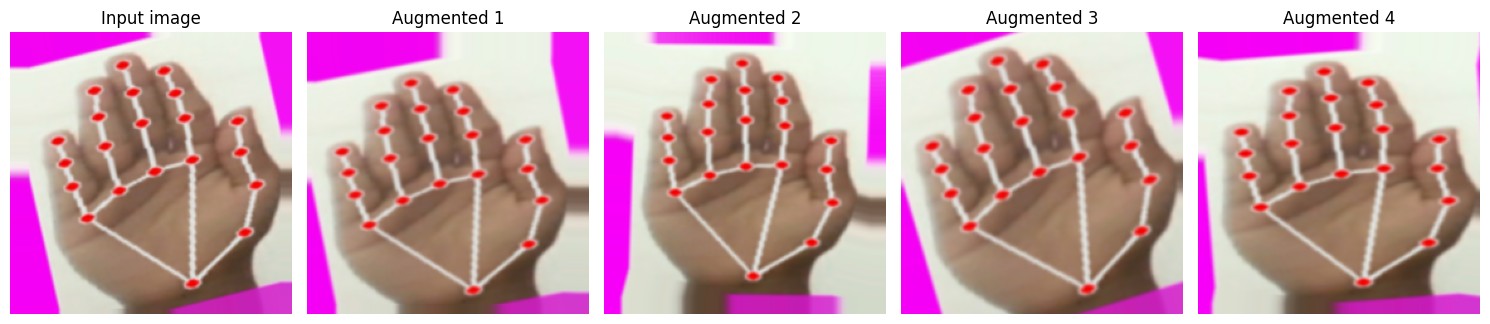

Input image shape: (224, 224, 3)
Class label: 1


In [14]:
# Get one image from the training dataset
images, labels = next(iter(train_ds))
original_image = images[0]

# Apply the augmentation pipeline several times to the same image
augmented_images = [
    data_augmentation(tf.expand_dims(original_image, axis=0), training=True)[0]
    for _ in range(4)
]

# Show the input and augmented results
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

axes[0].imshow(tf.clip_by_value(original_image, 0, 1))
axes[0].set_title("Input image")

for index, augmented_image in enumerate(augmented_images, start=1):
    axes[index].imshow(tf.clip_by_value(augmented_image, 0, 1))
    axes[index].set_title(f"Augmented {index}")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

print("Input image shape:", original_image.shape)
print("Class label:", int(labels[0]))

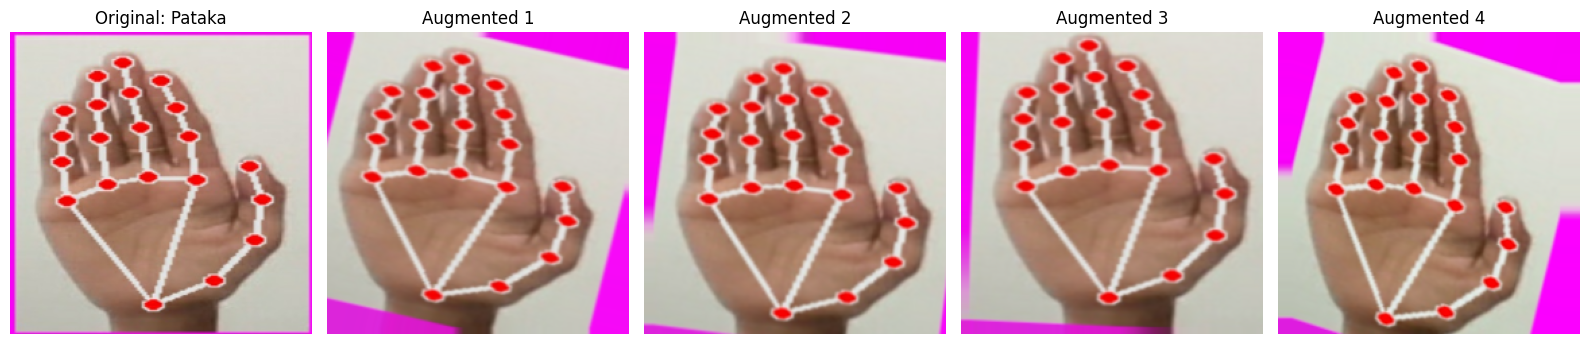

In [15]:
# Load an unaugmented training image
sample_image, sample_label = load_image(train_paths[0], train_labels[0])

# Generate four augmented versions
augmented_images = [
    data_augmentation(sample_image[tf.newaxis, ...], training=True)[0]
    for _ in range(4)
]

# Display the original beside its augmented versions
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

axes[0].imshow(tf.clip_by_value(sample_image, 0, 1))
axes[0].set_title(f"Original: {class_names[int(sample_label)]}")

for index, augmented_image in enumerate(augmented_images, start=1):
    axes[index].imshow(tf.clip_by_value(augmented_image, 0, 1))
    axes[index].set_title(f"Augmented {index}")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Assumes train_ds, val_ds, test_ds, and class_names are already defined.
# Images should be resized to 224x224 and normalized to [0, 1].

num_classes = len(class_names)
input_shape = (224, 224, 3)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ],
    name="custom_cnn",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Displays the CNN architecture and parameter counts.
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1,  # Shows epoch-by-epoch training output.
)

# Plot training and validation accuracy/loss.
epochs = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate once on the held-out test dataset.
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Display predictions for a batch of test images.
test_images, test_labels = next(iter(test_ds))
probabilities = model.predict(test_images, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)

count = min(8, len(test_images))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for index in range(count):
    axes[index].imshow(test_images[index])
    actual = class_names[int(test_labels[index])]
    predicted = class_names[int(predicted_labels[index])]
    axes[index].set_title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color="green" if actual == predicted else "red",
    )
    axes[index].axis("off")

for index in range(count, len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,877 (1.62 MB)

 Trainable params: 422,917 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/25


In [ ]:
# Tune two hyperparameters: learning rate and dropout rate.
learning_rates = [0.001, 0.0001]
dropout_rates = [0.3, 0.5]
num_classes = len(class_names)

def build_model(learning_rate, dropout_rate):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(224, 224, 3)),

            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.GlobalAveragePooling2D(),

            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

results = []
best_model = None
best_val_accuracy = -1

for learning_rate in learning_rates:
    for dropout_rate in dropout_rates:
        print(
            f"\nTraining trial: learning_rate={learning_rate}, "
            f"dropout_rate={dropout_rate}"
        )

        model = build_model(learning_rate, dropout_rate)
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=15,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_accuracy",
                    patience=3,
                    restore_best_weights=True,
                )
            ],
            verbose=1,
        )

        trial_val_accuracy = max(history.history["val_accuracy"])
        results.append(
            {
                "learning_rate": learning_rate,
                "dropout_rate": dropout_rate,
                "best_val_accuracy": trial_val_accuracy,
            }
        )

        print(f"Best validation accuracy: {trial_val_accuracy:.4f}")

        if trial_val_accuracy > best_val_accuracy:
            best_val_accuracy = trial_val_accuracy
            best_model = model
            best_parameters = {
                "learning_rate": learning_rate,
                "dropout_rate": dropout_rate,
            }

print("\nHyperparameter tuning results")
print("Learning rate | Dropout rate | Best validation accuracy")
for result in results:
    print(
        f"{result['learning_rate']:<13} | "
        f"{result['dropout_rate']:<12} | "
        f"{result['best_val_accuracy']:.4f}"
    )

print("\nBest parameters:", best_parameters)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

# Evaluate the best model on the held-out test dataset.
test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot validation accuracy for each hyperparameter combination.
trial_names = [
    f"LR={result['learning_rate']}\nDropout={result['dropout_rate']}"
    for result in results
]
validation_accuracies = [result["best_val_accuracy"] for result in results]

plt.figure(figsize=(9, 5))
plt.bar(trial_names, validation_accuracies)
plt.title("Hyperparameter Tuning: Validation Accuracy")
plt.xlabel("Hyperparameter combination")
plt.ylabel("Best validation accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
epochs = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Collect actual labels and predict labels for the test dataset
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_probabilities = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_probabilities, axis=1)

# Calculate and print evaluation scores
print(f"Accuracy:   {accuracy_score(y_true, y_pred):.4f}")
print(
    f"Precision: {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}"
)
print(
    f"Recall:    {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}"
)
print(
    f"F1-score:  {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}"
)

# Calculate and display the confusion matrix
class_labels = np.arange(len(class_names))
cm = confusion_matrix(y_true, y_pred, labels=class_labels)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
).plot(cmap="Blues", values_format="d", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Documentation: Dataset Analysis and Model Training

## Task 1: Dataset Analysis

### Is the dataset balanced?
The dataset is balanced. It contains 2,000 images across five mudra classes, with 400 images in each class (20% per class). The stratified split used in the notebook assigns 1,400 images to training, 300 to validation, and 300 to testing, preserving the same class proportions in each split.

### How might imbalance affect learning?
If some classes had many more examples than others, the CNN could become biased toward the larger classes. It might achieve deceptively good overall accuracy while missing examples from underrepresented mudras. Per-class precision, recall, F1-score, and a confusion matrix would help reveal this. Balancing the data or using class weights can help when imbalance is present.

### What image characteristics could make mudra recognition difficult?
Although the images have consistent dimensions (300 x 300 pixels), RGB format, and are all readable, recognition can still be affected by changes in hand orientation, lighting, background, skin tone, camera distance, cropping, or partial occlusion. Mudras with similar finger arrangements may also be difficult to distinguish, especially when the fingertips or spaces between fingers are unclear.

### Would increasing image resolution always improve performance?
No. The source images are 300 x 300 pixels and the model resizes them to 224 x 224. A higher input resolution may preserve small finger details if those details are being lost, but it cannot restore information missing from the source. It also increases computation and may encourage overfitting on a relatively small dataset. Resolution should be compared experimentally using the same data split and evaluation procedure.

## Task 2: Image Augmentation

### Which augmentation techniques preserve the semantic meaning of a hand gesture?
The notebook applies small rotations (up to about 18 degrees), translations (up to 5% in each direction), zoom (up to 10%), and contrast changes (up to 10%). These modest changes can represent normal differences in how a hand is photographed while preserving the finger arrangement and the identity of the mudra. Augmentation is applied to training data only; validation and test images remain unchanged.

### Which augmentations could hurt classification accuracy, and why?
Horizontal or vertical flips can change handedness or produce an unnatural pose, and may alter meaningful orientation cues. Large rotations, aggressive crops or zooms, and large translations can hide or move fingers out of the frame. Extreme brightness or contrast changes can also obscure finger boundaries. Such transformations can make an image inconsistent with its original class label.

## Task 3: CNN and Hyperparameter Tuning

### Effect of the hyperparameter choices
The notebook compares learning rates of 0.001 and 0.0001 with dropout rates of 0.3 and 0.5. The learning rate controls the size of each optimizer update: a smaller rate generally makes training updates more gradual. Dropout randomly disables a fraction of activations during training; the larger 0.5 rate provides stronger regularization than 0.3 and can reduce reliance on individual features.

The best of the four tested combinations was a learning rate of 0.0001 and dropout rate of 0.5. It achieved 98.67% best validation accuracy and 99.00% test accuracy. The other tested combinations achieved best validation accuracies of 20.00%, 31.33%, and 20.00%. These results identify the best setting among the tested values; they do not establish that it is universally optimal.

### Did the model show underfitting or overfitting?
The initial CNN run showed strong overfitting or a generalization failure: training accuracy rose from about 80% to nearly 99%, while validation accuracy stayed at 20% (chance level for five classes) and validation loss increased substantially. The tuned run behaved much better: its best training and validation accuracies were both about 99%, and test accuracy was 99%, so the saved tuned-run results do not show an obvious train-versus-validation overfitting gap.

Because the tuned score is very high, it is still worth checking that near-duplicate images or images from the same capture session do not appear across training, validation, and test splits. A split grouped by person or capture session would provide a stronger test of performance on new hands or recording conditions.

# For the Extra Bonus

In [ ]:
# Expects train_ds, val_ds, test_ds, and class_names to be defined.
# Datasets should contain 224x224 RGB images normalized to [0, 1].
num_classes = len(class_names)
epochs = 15
learning_rate = 0.0001

def build_custom_cnn():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(224, 224, 3)),

            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling2D(),

            tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.GlobalAveragePooling2D(),

            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(num_classes, activation="softmax"),
        ],
        name="custom_cnn",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_mobilenetv2():
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))

    # MobileNetV2 expects pixel values scaled to [-1, 1].
    x = tf.keras.layers.Rescaling(scale=2.0, offset=-1.0)(inputs)

    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_measure(model):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        )
    ]

    start = time.perf_counter()
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )
    training_seconds = time.perf_counter() - start
    return training_seconds


def measure_model_size_mb(model):
    # Measures the size of the saved Keras model file.
    with tempfile.TemporaryDirectory() as temp_dir:
        model_path = os.path.join(temp_dir, "model.keras")
        model.save(model_path)
        return os.path.getsize(model_path) / (1024 * 1024)


def measure_inference_speed(model, repetitions=100):
    # Benchmark batch-size-one inference after warm-up.
    sample_images, _ = next(iter(test_ds))
    sample_image = sample_images[:1]

    for _ in range(10):
        model(sample_image, training=False).numpy()

    start = time.perf_counter()
    for _ in range(repetitions):
        model(sample_image, training=False).numpy()
    elapsed = time.perf_counter() - start

    milliseconds_per_image = elapsed / repetitions * 1000
    images_per_second = repetitions / elapsed
    return milliseconds_per_image, images_per_second


models = {
    "Custom CNN": build_custom_cnn(),
    "MobileNetV2": build_mobilenetv2(),
}

results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    training_seconds = train_and_measure(model)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    size_mb = measure_model_size_mb(model)
    inference_ms, inference_images_per_second = measure_inference_speed(model)

    results[model_name] = {
        "accuracy": test_accuracy,
        "size_mb": size_mb,
        "training_seconds": training_seconds,
        "inference_ms": inference_ms,
        "inference_images_per_second": inference_images_per_second,
    }

print("\nModel comparison")
print(
    f"{'Model':<16} {'Test accuracy':>14} {'Size (MB)':>12} "
    f"{'Training (s)':>14} {'Inference (ms/image)':>22} {'Images/s':>12}"
)
print("-" * 94)

for model_name, result in results.items():
    print(
        f"{model_name:<16} "
        f"{result['accuracy']:>14.4f} "
        f"{result['size_mb']:>12.2f} "
        f"{result['training_seconds']:>14.2f} "
        f"{result['inference_ms']:>22.2f} "
        f"{result['inference_images_per_second']:>12.2f}"
    )

# Save trained models and class labels to persistent Google Drive storage.
from google.colab import drive
import json

drive.mount("/content/drive")
model_dir = Path("/content/drive/MyDrive/MudraProject/saved_models")
model_dir.mkdir(parents=True, exist_ok=True)

models["Custom CNN"].save(model_dir / "custom_cnn.keras")
models["MobileNetV2"].save(model_dir / "mobilenetv2.keras")

with open(model_dir / "class_names.json", "w") as file:
    json.dump(class_names, file)

print("Saved model files:", sorted(path.name for path in model_dir.iterdir()))